# Market Segmentation

### Problem

### We have given Ratings submitted by Customers and the Rating of their Loyality based on their Purchase, now we have to seperate them in different groups to make marketing strategy for them.

#### Importing Libraries required

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
sns.set()
from sklearn.cluster import KMeans


#### Loading data

In [2]:
data=pd.read_csv(r'C:\\Users\\DELL\\Desktop\\Market Segmentation.csv')

In [3]:
data

,Satisfaction,Loyalty
0,4,-1.33
1,6,-0.28
2,5,-0.99
3,7,-0.29
4,4,1.06
5,1,-1.66
6,10,-0.97
7,8,-0.32
8,8,1.02
9,8,0.68


#### Plot the Data

Text(0.5, 1.0, 'Costomer Loyalty & Satisfaction Plot')

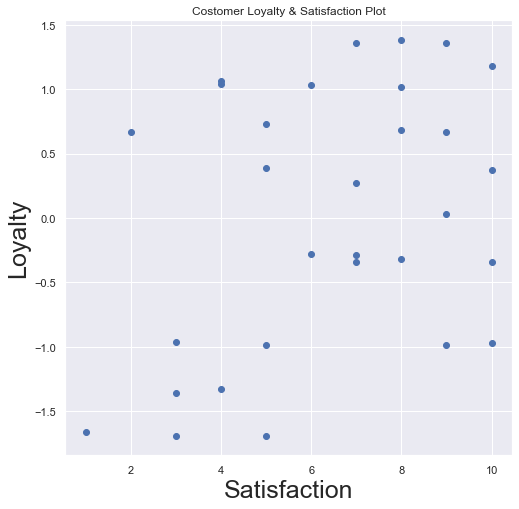

In [4]:
plt.figure(figsize=(8,8))
plt.scatter(data['Satisfaction'],data['Loyalty'])
plt.xlabel('Satisfaction',fontsize = 25)
plt.ylabel('Loyalty',fontsize = 25)
plt.title('Costomer Loyalty & Satisfaction Plot')

#### Select the features

In [5]:
x=data.copy()

#### Clustering

In [6]:
kmeans=KMeans()
kmeans.fit(x)

KMeans()

In [7]:
clusters =x.copy()

In [12]:
clusters['cluster_pred']= kmeans.fit_predict(x)
cmap = cm.get_cmap('viridis')  # or another colormap like 'plasma', 'inferno', etc.

C:\Users\DELL\AppData\Local\Temp\ipykernel_268\2686066597.py:6: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  plt.colorbar()


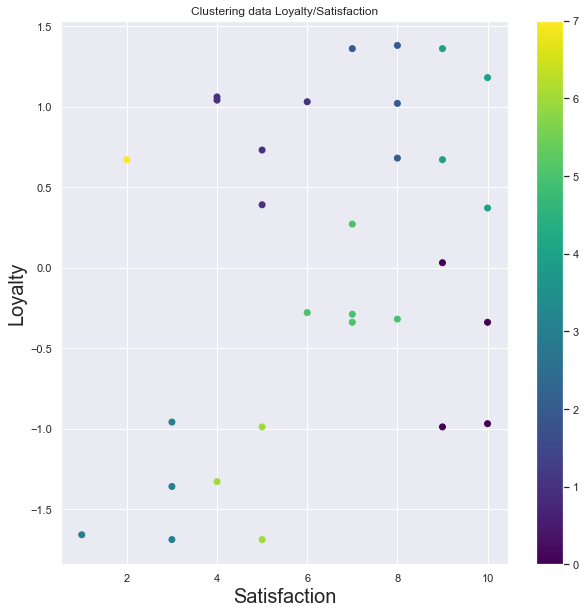

In [14]:
plt.figure(figsize=(10,10))
plt.scatter(clusters['Satisfaction'], clusters['Loyalty'],c=clusters['cluster_pred'],cmap=cmap)
plt.xlabel('Satisfaction', fontsize=20)
plt.ylabel('Loyalty',fontsize=20)
plt.title('Clustering data Loyalty/Satisfaction')
plt.colorbar() 

#### Standardize the variables

In [15]:
from sklearn import preprocessing
x_scaled=preprocessing.scale(x)
x_scaled

array([[-0.93138063, -1.3318111 ],
       [-0.15523011, -0.28117124],
       [-0.54330537, -0.99160391],
       [ 0.23284516, -0.29117733],
       [-0.93138063,  1.05964534],
       [-2.09560642, -1.6620122 ],
       [ 1.39707095, -0.97159172],
       [ 0.62092042, -0.32119561],
       [ 0.62092042,  1.01962097],
       [ 0.62092042,  0.67941378],
       [ 1.39707095, -0.3412078 ],
       [-0.54330537,  0.38923705],
       [-0.54330537, -1.69203048],
       [-1.70753116,  0.66940768],
       [ 0.23284516,  0.26916393],
       [ 1.00899568,  1.35982816],
       [ 0.62092042,  1.37984035],
       [ 0.23284516,  1.35982816],
       [ 0.23284516, -0.3412078 ],
       [ 1.00899568,  0.66940768],
       [ 1.39707095,  1.17971847],
       [-1.31945589, -1.69203048],
       [-0.93138063,  1.03963316],
       [-1.31945589, -0.96158562],
       [-0.15523011,  1.02962706],
       [ 1.00899568, -0.99160391],
       [ 1.39707095,  0.36922486],
       [ 1.00899568,  0.02901767],
       [-1.31945589,

#### Take advantage of the Elbow method

In [16]:
wcss=[]

for i in range(1,10):
    kmeans=KMeans(i)
    kmeans.fit(x_scaled)
    inert= kmeans.inertia_
    wcss.append(inert)
wcss

C:\ProgramData\Anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1036: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


[59.99999999999999,
 29.818973034723143,
 17.913349527387965,
 10.24718180592842,
 7.792695153937187,
 6.586212092192188,
 5.558520827037861,
 4.622832858801697,
 3.7978681376699055]

Text(0, 0.5, 'wcss')

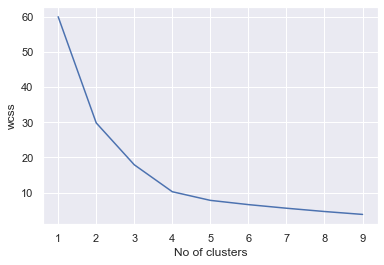

In [17]:
plt.plot(range(1,10),wcss)
plt.xlabel('No of clusters')
plt.ylabel('wcss')

###### From graph we can clearly see the 4 or 5 nos of cluster are best choice

#### Plotting Cluster Chart with 4 clusters

In [18]:
kmeans_4=KMeans(4)
kmeans_4.fit(x_scaled)
clusters_new=x.copy()
clusters_new['clusters_pred']=kmeans_4.fit_predict(x_scaled)

In [19]:
clusters_new

,Satisfaction,Loyalty,clusters_pred
0,4,-1.33,1
1,6,-0.28,3
2,5,-0.99,1
3,7,-0.29,3
4,4,1.06,2
5,1,-1.66,1
6,10,-0.97,3
7,8,-0.32,3
8,8,1.02,0
9,8,0.68,0


Text(0, 0.5, 'Loyalty')

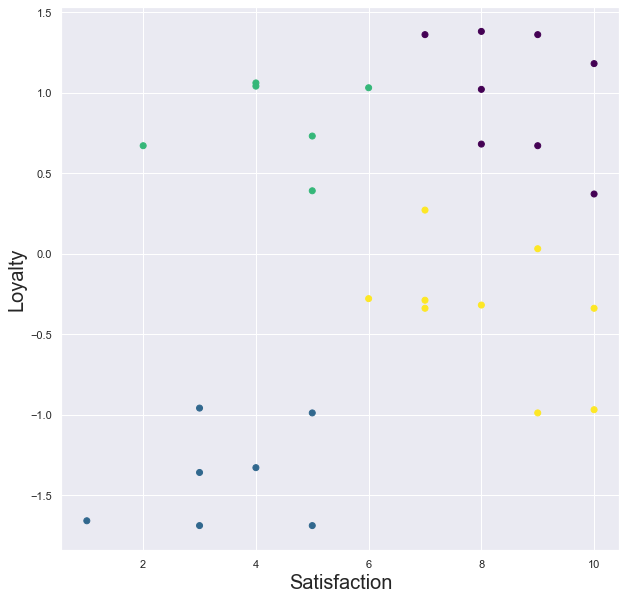

In [22]:
plt.figure(figsize=(10,10))
plt.scatter(clusters_new['Satisfaction'], clusters_new['Loyalty'], c=clusters_new['clusters_pred'], cmap=cmap)
plt.xlabel('Satisfaction',fontsize=20)
plt.ylabel('Loyalty',fontsize=20)

#### Plotting Graph with 5 clusters

In [23]:
kmeans_5=KMeans(5)
kmeans_5.fit(x_scaled)
clusters_new=x.copy()
clusters_new['clusters_pred']=kmeans_5.fit_predict(x_scaled)

In [26]:
plt.figure(figsize=(10,10))

<Figure size 720x720 with 0 Axes>

<Figure size 720x720 with 0 Axes>

Text(0, 0.5, 'Loyalty')

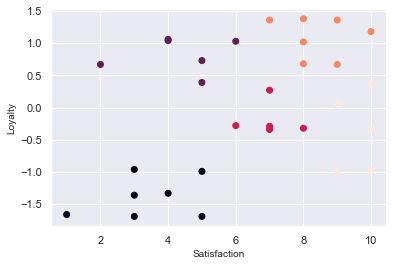

In [29]:
plt.scatter(clusters_new['Satisfaction'],clusters_new['Loyalty'],c=clusters_new['clusters_pred'])
plt.xlabel('Satisfaction',fontsize=10)
plt.ylabel('Loyalty',fontsize=10)

#### From analysing both graphs we can choose one which may be more useful for our needs

##### In this case we can take 4 clusters and 4 type of customers

###### 1.Fans- High satisfaction, high loyalty

###### 2.Roamers- High satisfaction, low loyalty

###### 3.Supporters- Low satisfaction, high loyalty

###### 4. Alieanated- Low satisfaction, low loyalty